In [12]:
%pip install ipykernel
%pip install astropy
%pip install numpy
%pip install matplotlib
%pip install photutils[all]
%pip install acstools

from IPython.display import clear_output
clear_output()

In [13]:
from astropy.io import fits
from matplotlib.colors import LogNorm
from acstools import acszpt
from astropy.stats import sigma_clipped_stats
from photutils.aperture import CircularAperture, CircularAnnulus, ApertureStats, aperture_photometry
from photutils.detection import DAOStarFinder
import matplotlib.pyplot as plt
import numpy as np


In [4]:
image_path = "/workspaces/seestar-photometry/data/NGC_6231/Light_ngc6231_5.0s_LP_20250911-193307.fit"
fits_file = fits.open(image_path)
print(fits_file)

<Figure size 640x480 with 0 Axes>

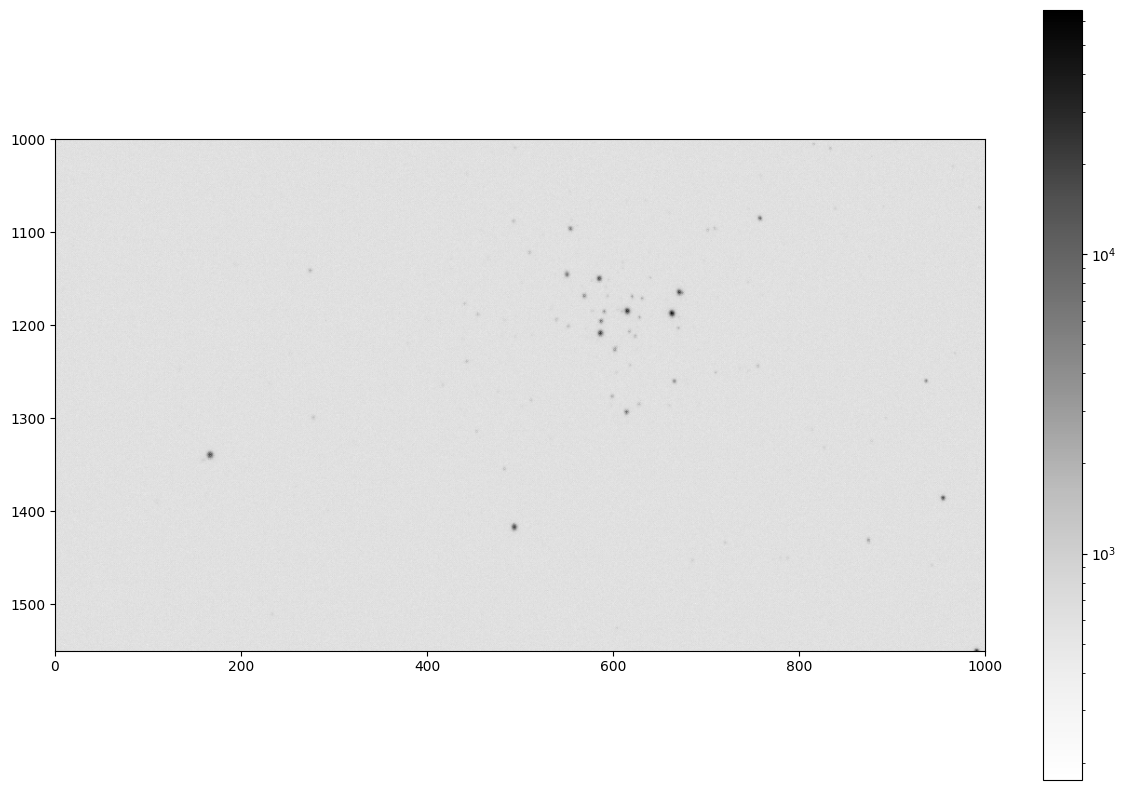

In [5]:
image_data = fits_file[0].data
plt.figure()
plt.figure(figsize=(15,10))#,dpi=250)
plt.imshow(image_data, origin = 'lower', norm = LogNorm(), cmap = 'Greys')
plt.ylim(bottom = 1000, top = 1550)
plt.xlim(left = 0, right = 1000)
plt.gca().invert_yaxis()
plt.colorbar()
plt.show()

In [6]:
mean, median, std = sigma_clipped_stats(image_data, sigma = 3.0)
print(mean, median, std)

609.0239657219435 607.0 57.18242437045895


In [7]:
daofind = DAOStarFinder(fwhm = 3.0, threshold = 5.0 * std)
sources = daofind(image_data - median)

for col in sources.colnames:
    if col not in ('id', 'npix'):
        sources[col].info.format = '%.2f'

sources.pprint(max_width = 76)

 id xcentroid ycentroid sharpness ...   peak      flux     mag   daofind_mag
--- --------- --------- --------- ... -------- ---------- ------ -----------
  1    671.80     42.02      0.26 ...   893.00   12328.00 -10.23       -1.08
  2    218.39    117.57      0.45 ...   336.00    2828.00  -8.63       -0.21
  3    124.10    154.14      0.55 ...   553.00    4247.00  -9.07       -0.71
  4    436.58    155.04      0.21 ...   281.00    3046.00  -8.71       -0.41
  5    577.22    190.16      0.58 ...   432.00    2766.00  -8.60       -0.37
  6    164.65    218.61      0.57 ...   435.00    2947.00  -8.67       -0.34
  7    380.43    291.49      0.39 ...   320.00    2580.00  -8.53       -0.32
  8    653.10    328.04      0.76 ...   675.00    3818.00  -8.95       -0.63
  9    679.82    331.89      0.42 ...   237.00    2148.00  -8.33       -0.06
 10     12.93    504.96      0.36 ...   477.00    4220.00  -9.06       -0.74
...       ...       ...       ... ...      ...        ...    ...         ...

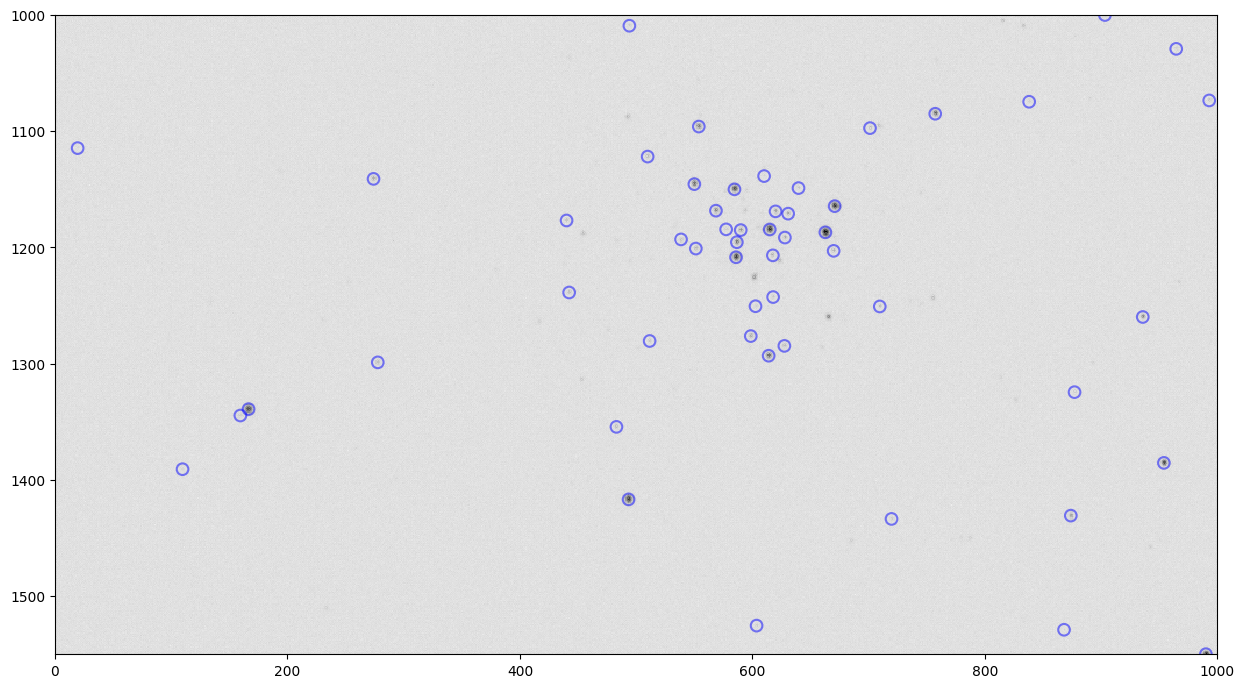

In [8]:
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
apertures = CircularAperture(positions, r = 5.0)
plt.figure(figsize=(15,10))#,dpi=250)
plt.imshow(image_data, cmap = 'Greys', origin = 'lower', norm  = LogNorm(), interpolation = 'nearest')
apertures.plot(color = 'b', lw = 1.5, alpha = 0.5);
plt.ylim(bottom = 1000, top = 1550)
plt.xlim(left = 0, right = 1000)
plt.gca().invert_yaxis()
plt.show()

In [9]:
print(apertures)

Aperture: CircularAperture
positions: [[ 671.80188417,   42.01587358],
            [ 218.39390059,  117.56674275],
            [ 124.09558421,  154.13796332],
            [ 436.57808602,  155.03598448],
            [ 577.22259317,  190.16451709],
            [ 164.6469133 ,  218.61191056],
            [ 380.43089131,  291.49353616],
            [ 653.10050984,  328.0419903 ],
            [ 679.81634477,  331.89065956],
            [  12.93386145,  504.95811772],
            [ 501.72263969,  510.99785969],
            [ 805.21914458,  542.22706607],
            [ 950.26791031,  543.15563213],
            [ 151.45158084,  556.49764194],
            [1075.0051086 ,  573.0822228 ],
            [ 118.7089886 ,  576.90495481],
            [ 611.37574336,  658.42753349],
            [ 890.38181703,  717.88789299],
            [ 487.76253636,  724.69027823],
            [ 404.02909431,  749.71016363],
            [ 763.7332513 ,  786.91061107],
            [1001.75214868,  794.67588531],
     

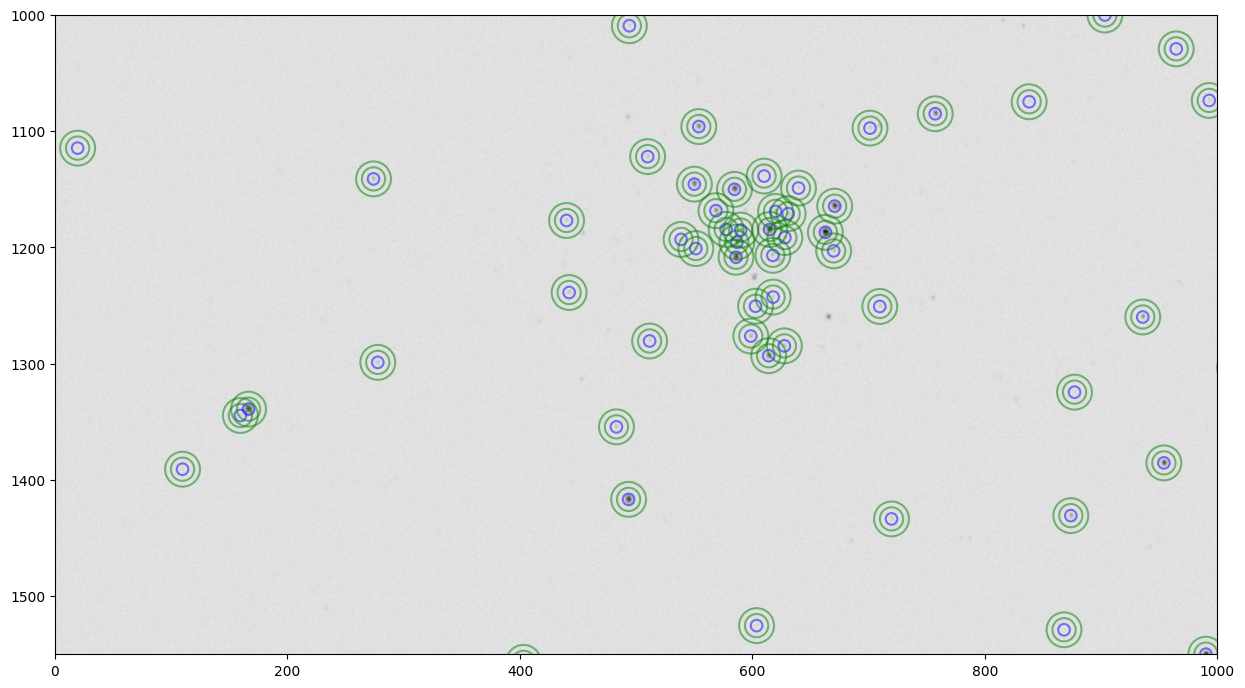

In [10]:
annulus_aperture = CircularAnnulus(positions, r_in =10.0, r_out = 15.0)
plt.figure(figsize = (15,10))
plt.imshow(image_data, cmap = 'Greys', norm = LogNorm(), origin = 'lower')
apertures.plot(color = 'b', lw = 1.5, alpha = 0.5);
annulus_aperture.plot(color = 'g', lw = 1.5, alpha = 0.5);
plt.ylim(bottom = 1000, top = 1550)
plt.xlim(left = 0, right = 1000)
plt.gca().invert_yaxis()
plt.show()

In [11]:
aperstats = ApertureStats(image_data, annulus_aperture)
bkg_mean = aperstats.mean
aperture_area = apertures.area_overlap(image_data)
total_bkg = bkg_mean*aperture_area

# perform aperture photometry
star_data = aperture_photometry(image_data, apertures)

# add backgrounds to table
star_data['total_bkg'] = total_bkg

# format and print data
for col in star_data.colnames:
    star_data[col].info.format = '%.8g'
star_data.pprint()

 id  xcenter   ycenter  aperture_sum total_bkg
--- --------- --------- ------------ ---------
  1 671.80188 42.015874     64641.58 47677.266
  2  218.3939 117.56674    51082.092 48049.025
  3 124.09558 154.13796    52761.974 47746.986
  4 436.57809 155.03598    52013.773 48008.116
  5 577.22259 190.16452    50321.936 47845.174
  6 164.64691 218.61191    50862.318 47713.744
  7 380.43089 291.49354    51126.402 47695.683
  8 653.10051 328.04199    52070.212 47416.122
  9 679.81634 331.89066    50737.789 47563.994
 10 12.933861 504.95812    52479.205 47718.519
...       ...       ...          ...       ...
 84 603.54324 1525.3429    51004.236 47850.733
 85 868.02493 1528.9182     47911.43 47909.488
 86 990.04436 1549.9181    254054.47 48559.789
 87 403.06428 1556.9173    64495.526 47895.299
 88 471.91122  1566.039     51171.69 48145.107
 89 1001.9023  1632.684    52423.228 48188.184
 90 481.66238 1655.4638    138633.32 48210.889
 91 10.276463 1743.7189    2121918.6 53758.375
 92 10.347773

In [ ]:
fits_file[0].header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 1080 / length of data axis 1                          
NAXIS2  =                 1920 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BZERO   =                32768 / offset data range to that of unsigned short    
BSCALE  =                    1 / default scaling factor                         
CREATOR = 'ZWO Seestar S50'    / Capture software                               
PRODUCER= 'ZWO     '           / Powered by ZWO                                 
XORGSUBF=                   

In [19]:
print(fits_file[0].header['DATE-OBS'])
print(fits_file[0].header['INSTRUME'])
print(fits_file[0].header['FILTER'])



2025-09-12T00:32:58.941915
Seestar S50
LP
